In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# To make results replicable
# WARNING: Setting a global seed like this would make the train and test data the same (same noise)
# np.random.seed(123)

### Helper functions

In [14]:
def generate_quadratic_data(N=1000):
    X = 2 * np.random.rand(N, 1)
    y = -3 + 0.5*X + X**2 - 0.2*X**3 + 0.1*X**4 + 0.2*np.random.randn(N, 1)
    return X, y

In [15]:
def generate_cubic_data(N=1000):
    X = 2 * np.random.rand(N, 1)
    y = 1 + 2*X - 0.5*X**2 + 0.7*X**3 + 0.2*np.random.randn(N, 1)
    return X, y

In [5]:
def build_polynomial_features(X, degree):
    """
    Build a polynomial design matrix Φ.
    Note: Polynomial regression = linear regression on nonlinear features.

    """
    
    X = X.reshape(-1, 1)
    Phi = np.ones((X.shape[0], degree + 1))
    for d in range(1, degree + 1):
        Phi[:, d] = X[:, 0]**d
    
    return Phi


In [6]:
def normal_equation(Phi, y_true, lam=0, mat_inv=False):
    """
    Compute the normal equation for linear regression.
    Optionally add regularisation to the normal equation.

    Args:
        Phi_mu (numpy array): Design matrix for the mean model, shape (n, d)
        y_true (numpy array): Target values, shape (n,)
        lam (float): Regularisation parameter (default: 0)
        mat_inv (bool): Whether to perform the (inefficient) matrix inversion.

    Returns:
        w (numpy array): Regression weights, shape (C,)
    
    """

    #Identity matrix, same size as the number of features (columns in Phi)
    I = np.eye(Phi.shape[1])

    #Do not regularise the bias term
    I[0, 0] = 0

    A = Phi.T @ Phi + lam * I
    b = Phi.T @ y_true

    if not mat_inv:
        # Avoid using matrix inversion
        w = np.linalg.solve(A, b)
    else:
        w = np.linalg.inv(A) @ b

    # Alternative simplified method
    #w = np.linalg.lstsq(Phi, y_true, rcond=None)[0]

    return w

In [7]:
def fit_polynomial(X, y, degree, lam=0, mat_inv=False):
    Phi = build_polynomial_features(X, degree)
    w = normal_equation(Phi, y, lam, mat_inv)
    y_pred = Phi @ w
    
    return w, Phi, y_pred

In [8]:
def predict_polynomial(X, w, degree):
    Phi = build_polynomial_features(X, degree)
    return Phi @ w

In [9]:
def plot_fitted_function(X, y_train, X_test, y_pred, plot_pred_as_line=True):
    """
    Plot the training data as a scatter plot and overlay the fitted function.
    The plot may compare the train data with the test fitted function, but also 
    the trian data with the trainining fitted function and so on.
    
    Args:
        X (numpy array): Training input features, shape (n,)
        y_train (numpy array): Training target values, shape (n,)
        X_test (numpy array): Test input features, shape (n,)
        y_pred (numpy array): Predicted outputs for the test inputs, shape (n,)
        plot_pred_as_line (bool): Plot the predictions as a continous line (fitted function) 
                            or scatter plot. Default is True.

    """

    plt.figure(figsize=(10, 6))
    
    # Scatter plot of the training data
    plt.scatter(X, y_train, color="blue", label="Training Data", alpha=0.8, s=15)
    
    # Plot the fitted function
    if plot_pred_as_line == True:
        # Sort X_test and corresponding mu for smooth line plotting
        sorted_indices = np.argsort(X_test.ravel())
        X_sorted = X_test.ravel()[sorted_indices]
        mu_sorted = y_pred.ravel()[sorted_indices]

        # Predicted mean as a continuous function (line plot)
        plt.plot(X_sorted, mu_sorted, color="green", label="Predicted Mean", linewidth=2)
    elif plot_pred_as_line == False:
        plt.scatter(X_test, y_pred, color="green", label="Predictions", alpha=0.8, s=15)
    else:
        raise ValueError("Invalid input for 'plot_pred_as_line'. Please select True or False.")
    
    plt.xlabel("Input Feature")
    plt.ylabel("Target Value")
    plt.title("Fitted Function vs Training Data")
    plt.legend()
    plt.show()


In [10]:
def plot_models_on_data(X, y, X_list, y_pred_list, degrees):
    """
    Plot training data and several model predictions on top of it.

    Args:
        X (np.ndarray): Training inputs
        y (np.ndarray): Training targets
        X_list (list): List of X arrays for each model (they are usually all the same)
        y_pred_list (list): List of predicted y for each model
        degrees (list): Polynomial degrees for labeling
    
    """

    plt.figure(figsize=(10, 6))

    # Plot original data
    plt.scatter(X, y, s=12, c="blue", label="Training Data", alpha=0.25)

    # Color cycle
    colors = ["red", "green", "purple", "brown", "black", "orange"]

    for i, (X_model, y_model) in enumerate(zip(X_list, y_pred_list)):
        deg = degrees[i]

        # Choose label based on degree
        if deg == 1:
            label = "Linear"
        elif deg == 2:
            label = "Quadratic"
        elif deg == 3:
            label = "Cubic"
        else:
            label = f"Degree {deg}"

        color = colors[i % len(colors)]

        # Plot predictions as scatter (just like your example)
        plt.scatter(X_model, y_model, s=10, c=color, label=label, alpha=0.85)

    plt.legend()
    plt.xlabel("X")
    plt.ylabel("y")
    plt.title("Comparing Polynomial Fits")
    plt.show()


### Modelling

Fitted functions parameters (the first parameter is the bias term).
Quadratic parameters: [-2.91431572  0.19528463  1.11113582]
Cubic parameters: [ 1.01270669  1.95034916 -0.42639274  0.67637417]


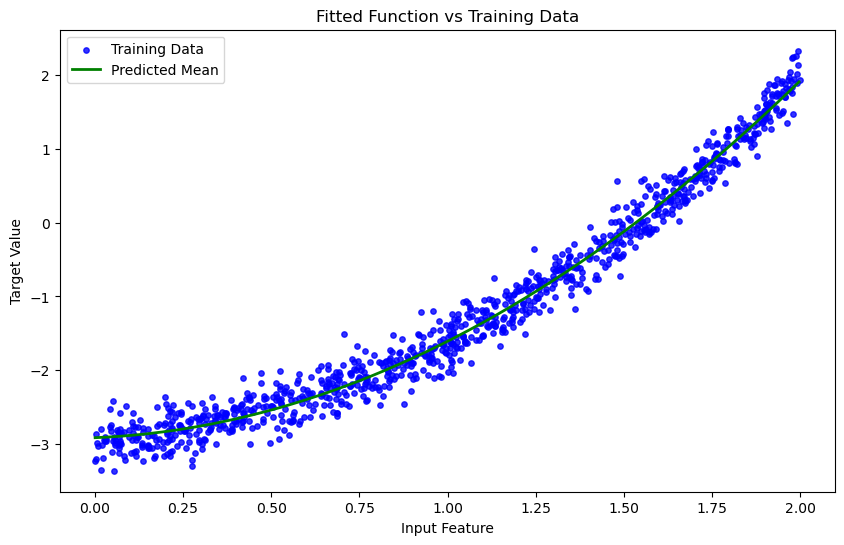

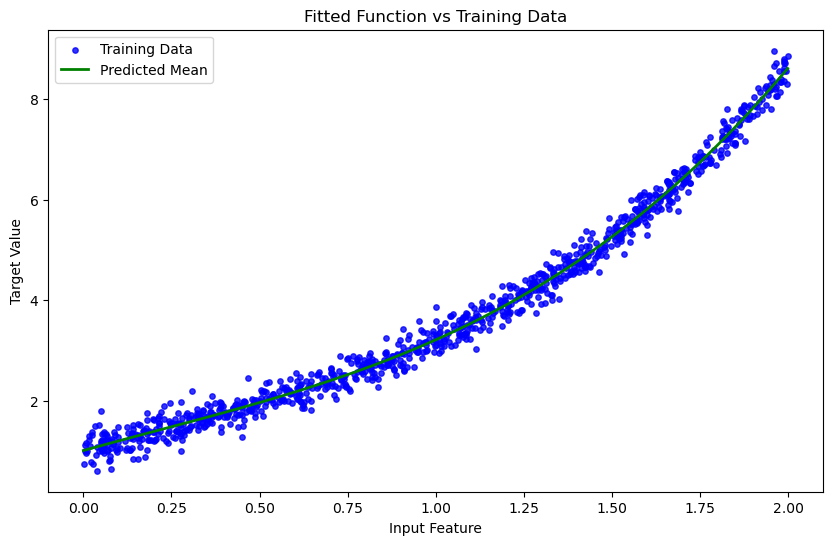

In [16]:
# Generate training data with random noise
Xq_train, yq_train = generate_quadratic_data()
Xc_train, yc_train = generate_cubic_data()

# Fit the models
# Use the original matrix inversion method for this experiment (for educational purposes), although very expensive
wq, Phiq, yq_pred_train = fit_polynomial(Xq_train, yq_train, degree=2, mat_inv=True)
wc, Phic, yc_pred_train = fit_polynomial(Xc_train, yc_train, degree=3, mat_inv=True)

print("Fitted functions parameters (the first parameter is the bias term).")
print("Quadratic parameters:", wq.ravel())
print("Cubic parameters:", wc.ravel())

# Generate test data (same functions but different random noise)
Xq_test, yq_test = generate_quadratic_data()
Xc_test, yc_test = generate_cubic_data()

# Predict on test data using the fitted parameters
yq_pred_test = predict_polynomial(Xq_test, wq, degree=2)
yc_pred_test = predict_polynomial(Xc_test, wc, degree=3)

# Plot data and results
plot_fitted_function(Xq_train, yq_train, Xq_test, yq_pred_test, plot_pred_as_line=True)
plot_fitted_function(Xc_train, yc_train, Xc_test, yc_pred_test, plot_pred_as_line=True)

Fitted functions parameters (the first parameter is the bias term).
Linear parameters: [0.25538318 3.48671542]
Quadratic parameters: [1.28020622 0.32866657 1.59944715]
Cubic parameters: [ 1.01270669  1.95034916 -0.42639274  0.67637417]


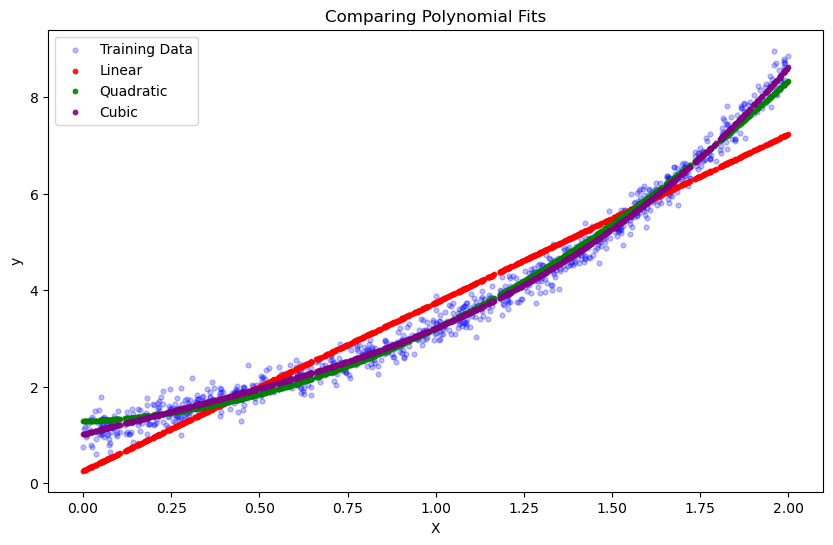

In [17]:
# Fit different models on the same cubic data visualise the differences
w1, _, y1 = fit_polynomial(Xc_train, yc_train, degree=1)
w2, _, y2 = fit_polynomial(Xc_train, yc_train, degree=2)
w3, _, y3 = fit_polynomial(Xc_train, yc_train, degree=3)

print("Fitted functions parameters (the first parameter is the bias term).")
print("Linear parameters:", w1.ravel())
print("Quadratic parameters:", w2.ravel())
print("Cubic parameters:", w3.ravel())

plot_models_on_data(
    X=Xc_train,
    y=yc_train,
    X_list=[Xc_train, Xc_train, Xc_train], # The dataset is the same for every function
    y_pred_list=[y1, y2, y3],
    degrees=[1, 2, 3]
)


Whereas the linear model (polynomial with `degree=1`) underfits the data, the quadratic model looks almost as good as the cubic polynomial in fitting the data, but with less computational cost (simpler polynomial function). However, the visual results should be evaluated numerically as well, and even if the error is not being calculated in this simple exercise, that should be the main evaluation metric, especially because a 2D plot does not fully capture the complexity of cubic data.